<a href="https://colab.research.google.com/github/TanishqBhatnagar312/Capstone_Project_IDRA_P8/blob/main/AQIProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (18265, 16)
        City    Datetime  PM2.5   PM10     NO   NO2    NOx   NH3    CO   SO2  \
0      Delhi  2015-01-01  153.3  241.7  182.9  33.0   81.3  38.5  1.87  64.5   
1     Mumbai  2015-01-01   70.5  312.7  195.0  42.0  122.5  31.5  7.22  83.8   
2    Chennai  2015-01-01  174.1  275.4   56.2  68.8  230.9  28.5  8.56  60.8   
3    Kolkata  2015-01-01  477.2  543.9   14.1  76.4  225.9  45.6  2.41  42.1   
4  Bangalore  2015-01-01  171.6  117.7  123.3  12.4   61.9  49.7  1.26  79.7   

      O3  Benzene  Toluene  Xylene    AQI    AQI_Bucket  
0   83.6    18.93    20.81    8.32  204.5        Severe  
1  108.0     2.01    19.41    2.86   60.9  Satisfactory  
2   43.9    19.07    10.19    9.63  486.5        Severe  
3  171.1     9.31    11.65    9.39  174.4     Very Poor  
4  164.3     6.04    12.74    9.59  489.7          Good  
Missing Values:

Total Missing Values: 0
Duplicate Records: 0
Before Conversion:
City           object
Datetime       object
PM2.5         float

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,PM2.5,125.70,376.20,250.50,-250.050,751.950,0
1,PM10,150.10,450.00,299.90,-299.750,899.850,0
2,NO,50.60,151.00,100.40,-100.000,301.600,0
3,NO2,37.70,113.20,75.50,-75.550,226.450,0
4,NOx,63.10,188.90,125.80,-125.600,377.600,0
5,NH3,12.60,37.60,25.00,-24.900,75.100,0
6,CO,2.49,7.51,5.02,-5.040,15.040,0
7,SO2,24.40,75.10,50.70,-51.650,151.150,0
8,O3,50.60,150.40,99.80,-99.100,300.100,0
9,Benzene,5.08,15.11,10.03,-9.965,30.155,0


Features:
['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

Target: AQI
Training samples: 14612
Testing samples: 3653
Preprocessing pipeline created.


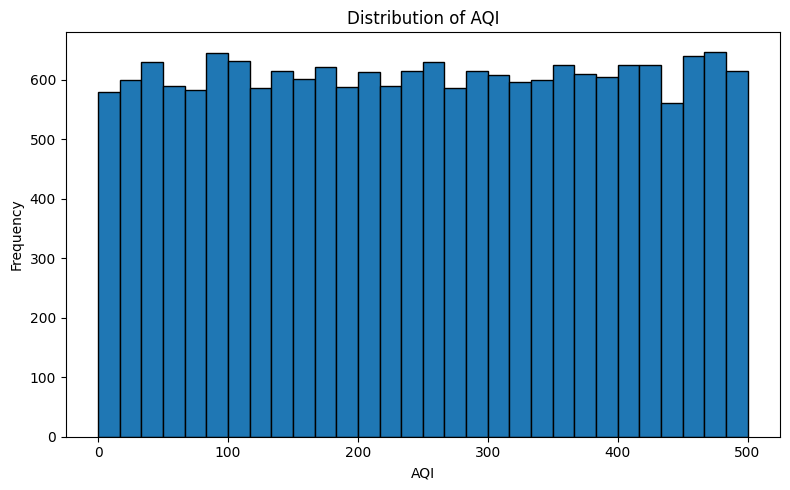




The histogram illustrates the distribution of AQI values within the dataset.
AQI values exhibit substantial variation, with observations distributed across a broad range.
The mean AQI is approximately 251.11, while the standard deviation is approximately 144.50,
indicating considerable variability in air-quality conditions represented in the dataset.





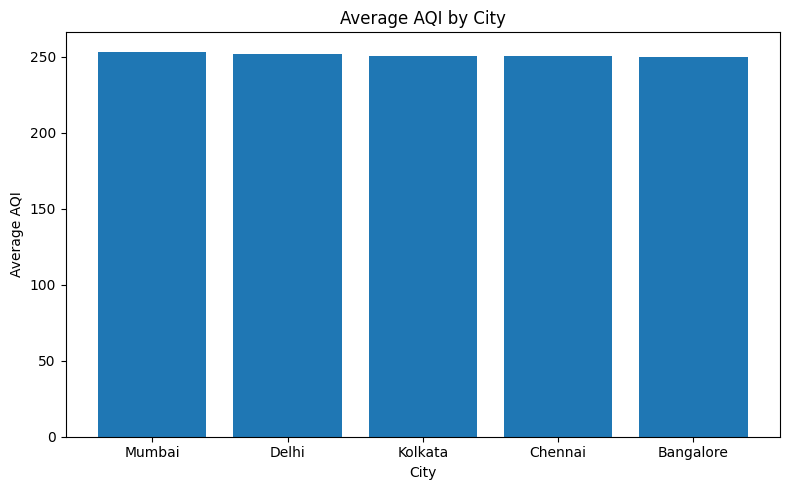




The city-wise comparison shows relatively small differences in average AQI among the five cities.
Mumbai records the highest mean AQI in the dataset, while Bangalore records the lowest.
However, the differences are small relative to the overall variation in AQI.



city_aqi


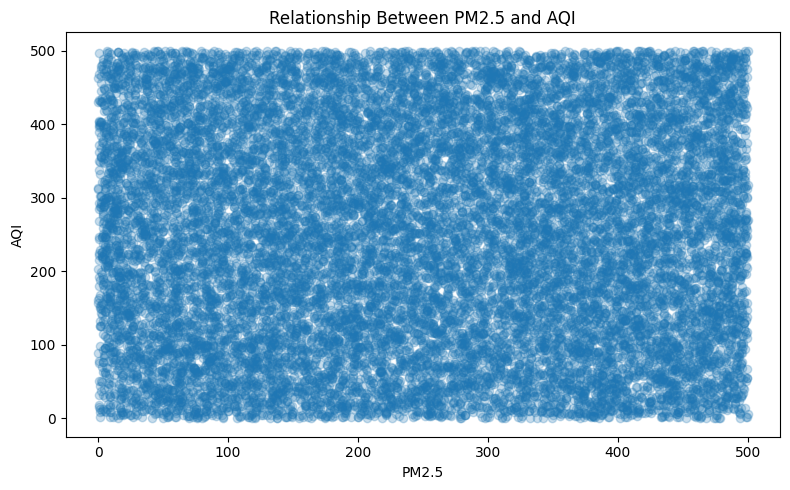




The scatter plot does not reveal a clear linear relationship between PM2.5 and AQI in the supplied
dataset. The observations are widely dispersed across the plot, suggesting that PM2.5 alone does not
provide a strong linear explanation of AQI variation within these observations.





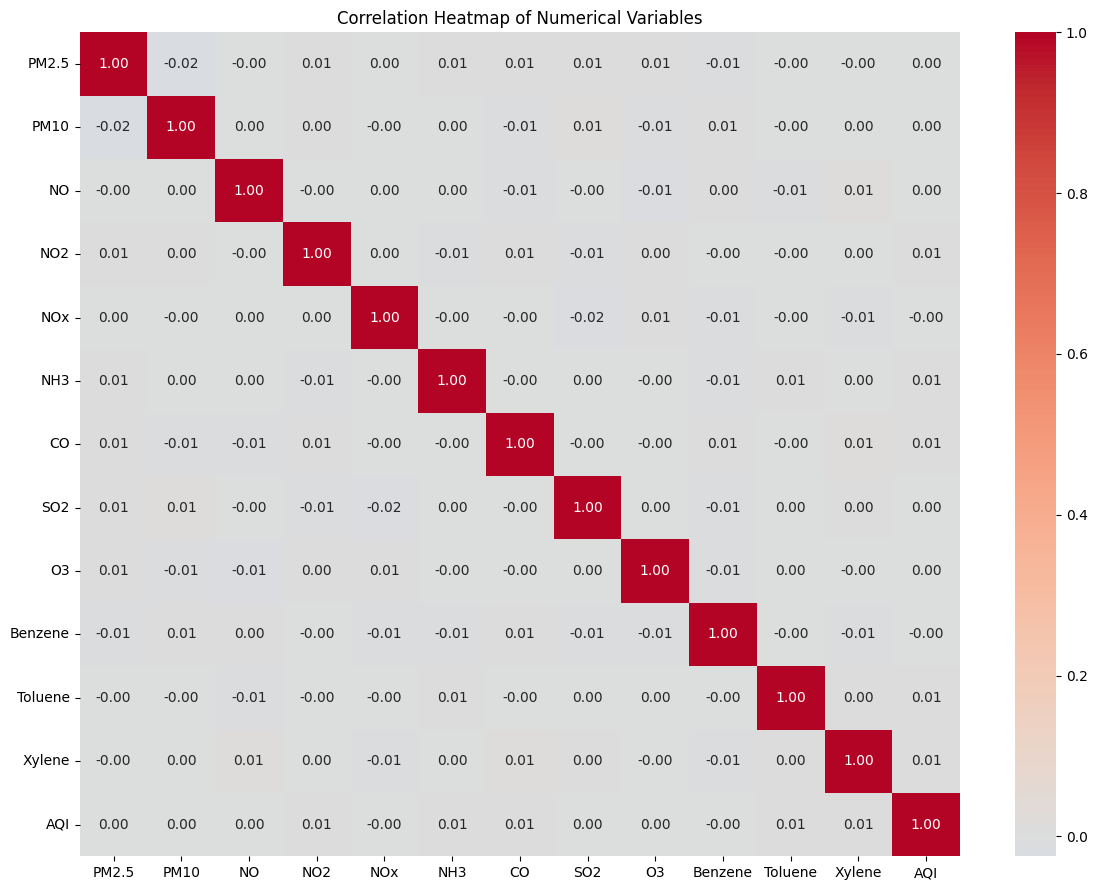




The correlation heatmap shows that the available pollutant variables have very weak linear correlations
with AQI in the supplied dataset. The strongest correlation with AQI is observed for NO2, although its
coefficient remains close to zero. This suggests that the available
numerical predictors do not exhibit strong linear associations with the target variable





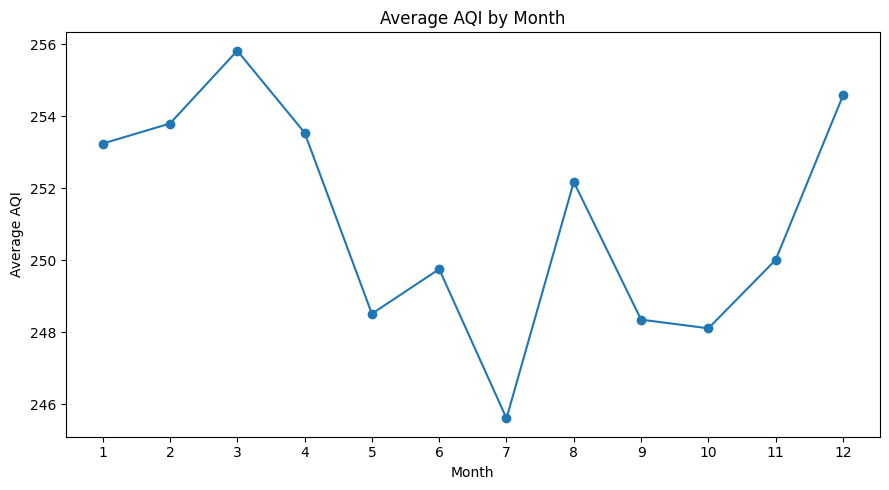




The monthly AQI trend illustrates how average AQI varies across the months represented in the dataset.
The observed pattern indicates temporal variation in AQI, although the analysis is descriptive and does
not establish that month itself causes changes in air quality.





,Mean,Median,Std Dev,Variance,Range,min,Q1,Q3,IQR,max
PM2.5,250.60,251.0,144.46,20868.78,499.9,0.0,125.70,376.20,250.50,499.9
PM10,299.44,300.3,173.48,30095.28,600.0,0.0,150.10,450.00,299.90,600.0
NO2,75.42,76.0,43.46,1888.78,150.0,0.0,37.70,113.20,75.50,150.0
CO,5.00,5.0,2.89,8.35,10.0,0.0,2.49,7.51,5.02,10.0
SO2,49.84,49.9,28.99,840.35,100.0,0.0,24.40,75.10,50.70,100.0
O3,100.41,100.7,57.59,3316.77,200.0,0.0,50.60,150.40,99.80,200.0
AQI,251.11,251.2,144.50,20881.01,500.0,0.0,125.40,376.40,251.00,500.0


,Correlation with AQI
NO2,0.011124
Xylene,0.010412
Toluene,0.009428
NH3,0.008079
CO,0.006046
SO2,0.002949
NO,0.001923
PM10,0.001245
PM2.5,0.000655
O3,0.000591


    Datetime  Year  Month  DayOfWeek
0 2015-01-01  2015      1          3
1 2015-01-01  2015      1          3
2 2015-01-01  2015      1          3
3 2015-01-01  2015      1          3
4 2015-01-01  2015      1          3
Linear Regression trained.
Random Forest trained.


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,124.6275,20828.1597,144.3196,-0.0009
1,Random Forest,125.4644,21254.1564,145.7881,-0.0214


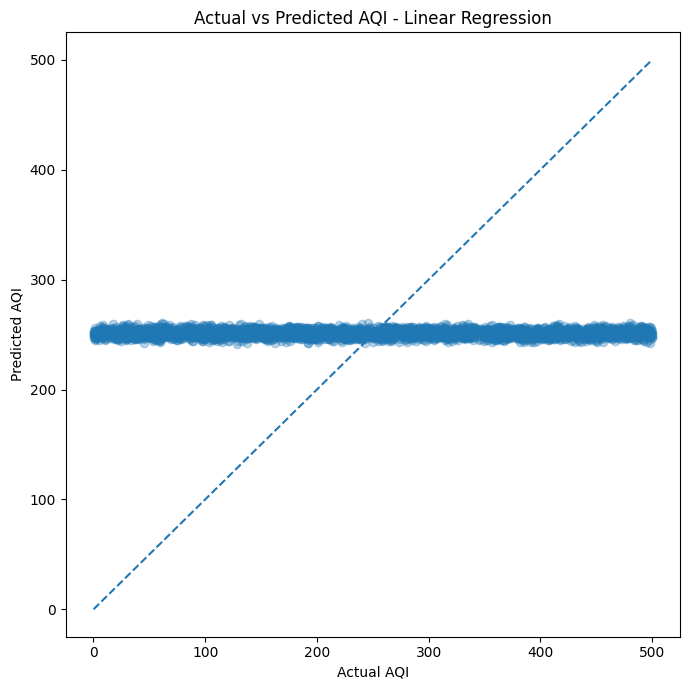


 The actual-versus-predicted plot shows substantial dispersion around the ideal prediction line.
The absence of a clear concentration of points around the diagonal indicates that
the model has limited ability to accurately estimate AQI from the available predictors.



,Model,Train R2,Test R2
0,Linear Regression,0.0005,-0.0009
1,Random Forest,0.8579,-0.0214


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("P_8_city_day.csv")

print("Dataset Shape:", df.shape)
print(df.head())
missing = df.isnull().sum()

print("Missing Values:")
print("\nTotal Missing Values:", df.isnull().sum().sum())

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

print("Before Conversion:")
print(df.dtypes)

df["Datetime"] = pd.to_datetime(df["Datetime"])

print("\nAfter Conversion:")
print(df.dtypes)

num_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append([col, q1, q3, iqr, lower, upper, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Variable", "Q1", "Q3", "IQR",
             "Lower Bound", "Upper Bound", "Outliers"]
)

display(outlier_df)

X = df.drop(columns=["AQI", "AQI_Bucket", "Datetime"])
y = df["AQI"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:", y.name)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

categorical_features = ["City"]

numerical_features = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created.")

plt.figure(figsize=(8, 5))

plt.hist(df["AQI"], bins=30, edgecolor="black")

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
print("\n")
print("\nThe histogram illustrates the distribution of AQI values within the dataset.")
print("AQI values exhibit substantial variation, with observations distributed across a broad range.")
print("The mean AQI is approximately 251.11, while the standard deviation is approximately 144.50,")
print("indicating considerable variability in air-quality conditions represented in the dataset.\n")
print("\n")
city_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

plt.bar(city_aqi.index, city_aqi.values)

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")

plt.tight_layout()
plt.show()

print("\n")
print("\nThe city-wise comparison shows relatively small differences in average AQI among the five cities.")
print("Mumbai records the highest mean AQI in the dataset, while Bangalore records the lowest.")
print("However, the differences are small relative to the overall variation in AQI.\n")
print("\n")

print("city_aqi")

plt.figure(figsize=(8, 5))

plt.scatter(
    df["PM2.5"],
    df["AQI"],
    alpha=0.25
)

plt.title("Relationship Between PM2.5 and AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()

print("\n")
print("\nThe scatter plot does not reveal a clear linear relationship between PM2.5 and AQI in the supplied")
print("dataset. The observations are widely dispersed across the plot, suggesting that PM2.5 alone does not")
print("provide a strong linear explanation of AQI variation within these observations.\n")
print("\n")

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

print("\n")
print("\nThe correlation heatmap shows that the available pollutant variables have very weak linear correlations")
print("with AQI in the supplied dataset. The strongest correlation with AQI is observed for NO2, although its")
print("coefficient remains close to zero. This suggests that the available")
print("numerical predictors do not exhibit strong linear associations with the target variable\n")
print("\n")

df["Month"] = df["Datetime"].dt.month

monthly_aqi = df.groupby("Month")["AQI"].mean()

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_aqi.index,
    monthly_aqi.values,
    marker="o"
)

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()
print("\n")
print("\nThe monthly AQI trend illustrates how average AQI varies across the months represented in the dataset.")
print("The observed pattern indicates temporal variation in AQI, although the analysis is descriptive and does")
print("not establish that month itself causes changes in air quality.\n")
print("\n")

stats_cols = [
    "PM2.5", "PM10", "NO2",
    "CO", "SO2", "O3", "AQI"
]

stats = df[stats_cols].describe().T

stats["Variance"] = df[stats_cols].var()
stats["Range"] = df[stats_cols].max() - df[stats_cols].min()
stats["IQR"] = (
    df[stats_cols].quantile(0.75)
    - df[stats_cols].quantile(0.25)
)

stats = stats[
    ["mean", "50%", "std", "Variance",
     "Range", "min", "25%", "75%", "IQR", "max"]
]

stats = stats.rename(columns={
    "50%": "Median",
    "25%": "Q1",
    "75%": "Q3",
    "mean": "Mean",
    "std": "Std Dev"
})

display(stats.round(2))

aqi_corr = (
    df.select_dtypes(include=np.number)
    .corr()["AQI"]
    .drop("AQI")
    .sort_values(ascending=False)
)

display(aqi_corr.to_frame("Correlation with AQI"))

df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["DayOfWeek"] = df["Datetime"].dt.dayofweek

print(df[["Datetime", "Year", "Month", "DayOfWeek"]].head())

lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression trained.")

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained.")

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return [name, mae, mse, rmse, r2]


results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

display(results_df.round(4))

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    lr_pred,
    alpha=0.3
)

min_val = min(y_test.min(), lr_pred.min())
max_val = max(y_test.max(), lr_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.title("Actual vs Predicted AQI - Linear Regression")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.tight_layout()
plt.show()

print("\n The actual-versus-predicted plot shows substantial dispersion around the ideal prediction line.")
print("The absence of a clear concentration of points around the diagonal indicates that")
print("the model has limited ability to accurately estimate AQI from the available predictors.\n")

lr_train_pred = lr_model.predict(X_train)
rf_train_pred = rf_model.predict(X_train)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Train R2": [
        r2_score(y_train, lr_train_pred),
        r2_score(y_train, rf_train_pred)
    ],
    "Test R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

display(comparison.round(4))

